                                             journey  journey_count  \
0  Hyde Park Corner, Hyde Park to Hyde Park Corne...         157171   
1   Albert Gate, Hyde Park to Albert Gate, Hyde Park          86432   
2  Black Lion Gate, Kensington Gardens to Black L...          83532   
3  Triangle Car Park, Hyde Park to Triangle Car P...          69580   
4     Park Lane , Hyde Park to Park Lane , Hyde Park          60110   

   distance_in_meters  av_duration_s  
0                 0.0    3112.101927  
1                 0.0    2759.726849  
2                 0.0    3107.997151  
3                 0.0    2801.695961  
4                 0.0    3299.885759  
Index(['journey', 'journey_count', 'distance_in_meters', 'av_duration_s'], dtype='str')

Cluster counts:
cluster
2    44906
0    34625
1     8003
Name: count, dtype: int64

Cluster 0:
0    Hyde Park Corner, Hyde Park to Hyde Park Corne...
1     Albert Gate, Hyde Park to Albert Gate, Hyde Park
3    Triangle Car Park, Hyde Park to Triangle

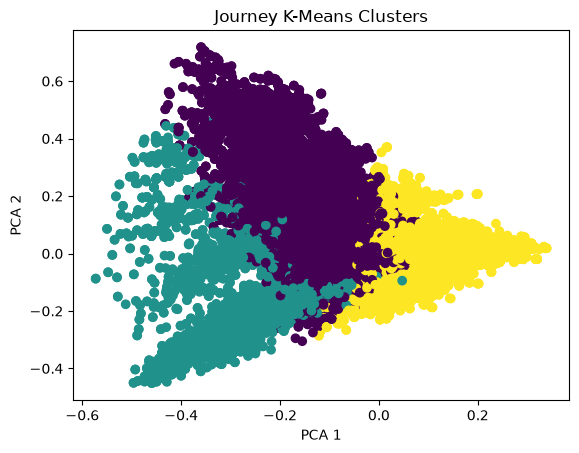


Saved: journeys_clustered.csv


In [1]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 2. Load dataset
df = pd.read_csv("journeys.csv")
print(df.head())
print(df.columns)

# 3. NLP preprocessing
text_col = "journey"
df[text_col] = df[text_col].fillna("").astype(str)
df["clean_text"] = df[text_col].str.lower().str.replace(r"[^a-z\s]", "", regex=True)

# 4. TF-IDF
tfidf = TfidfVectorizer(stop_words="english")
X = tfidf.fit_transform(df["clean_text"])

# 5. K-Means clustering
k = 3
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = model.fit_predict(X)

# 6. Show clusters
print("\nCluster counts:")
print(df["cluster"].value_counts())

for i in range(k):
    print(f"\nCluster {i}:")
    print(df[df["cluster"] == i][text_col].head())

# 7. Visualise
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Journey K-Means Clusters")
plt.show()

# 8. Save results
df.to_csv("journeys_clustered.csv", index=False)
print("\nSaved: journeys_clustered.csv")